In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore', category=UserWarning)

from sklearn.model_selection import train_test_split,GridSearchCV,RandomizedSearchCV,cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer

# 评价指标
from sklearn.metrics import (
    mean_absolute_error,mean_squared_error,r2_score,accuracy_score,precision_score,
    recall_score,f1_score,roc_auc_score,roc_curve,confusion_matrix,classification_report
)   # precision精确率:判断为正的样本,里面是正的概率;recall召回率:真实的正样本里面,被模型找出来多少,F1_score:Precision和recall的调和平均
plt.rcParams['font.family'] = ['Microsoft YaHei', 'SimHei', 'Noto Sans SC', 'sans-serif']
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Noto Sans SC', 'Microsoft JhengHei', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False
plt.rcparams['axes.unicode_minus'] = False  # 解决负号'-'显示为方块的问题

AttributeError: module 'matplotlib.pyplot' has no attribute 'rcparams'

##### 一.分类任务(乳腺癌数据集)

In [21]:
# 数据加载;划分特征与标签
clf_data=load_breast_cancer()
X_clf=pd.DataFrame(clf_data.data,columns=clf_data.feature_names)
y_clf=clf_data.target

# 划分数据集,分类任务需要按照标签进行分层划分
X_clf_train,X_clf_test,y_clf_train,y_clf_test=train_test_split(X_clf,y_clf,test_size=0.2,stratify=y_clf,random_state=RANDOM_STATE)

# 标准化(逻辑回归需要)
scaler=StandardScaler()
X_clf_train_scaled=scaler.fit_transform(X_clf_train)
X_clf_test_scaled=scaler.transform(X_clf_test)

1.逻辑回归

Logistic最优参数:{'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
逻辑回归准确率:0.9737
精确率precision:0.9861
召回率recall:0.9726
F1-score:0.9793
AUC:0.9957
详细分类报告:              precision    recall  f1-score   support

          恶性       0.95      0.98      0.96        41
          良性       0.99      0.97      0.98        73

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



d:\python\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

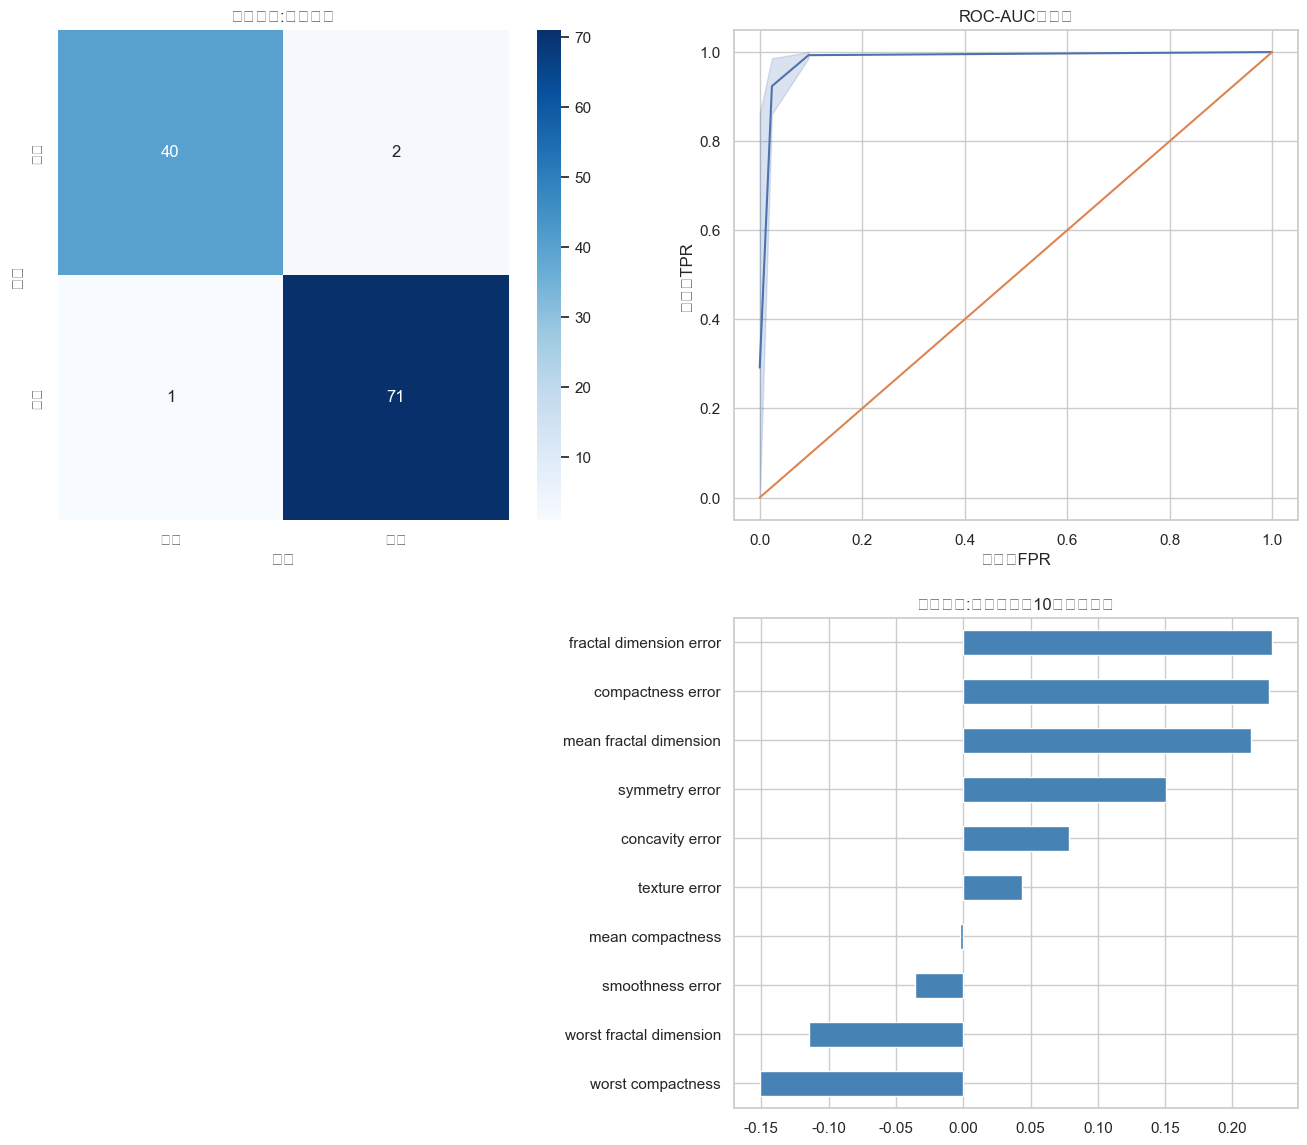

In [22]:
from sklearn.linear_model import LogisticRegression

# 1.训练基础数据
log_reg=LogisticRegression(max_iter=5000,random_state=RANDOM_STATE) # max_iter表示最大迭代次数
log_reg.fit(X_clf_train_scaled,y_clf_train) # 逻辑回归必须用标准化后的数据

# 2.调参方法
# 关键超参数:①C-正则强度倒数,C越大正则越弱(越容易过拟合) ②penalty:正则类型L1/L2/ElasticNet ③solver:优化算法
# 注意solver和penalty的兼容性,因此要分开写3组字典
log_params=[
    {'penalty':['l2'],'C':[0.001,0.01,0.1,1,10,100],'solver':['lbfgs']},   # 二阶拟牛顿法(仅支持L2)
    {'penalty':['l1'],'C':[0.001,0.01,0.1,1,10],'solver':['liblinear']},   # 专门小样本二分类,支持L1/L2
    {'penalty':['elasticnet'],'C':[0.01,0.1,1,10],'solver':['saga'],'l1_ratio':[0.2,0.5,0.8]} # 方差缩减随机梯度(全支持,适合大数据)
    ]
log_grid=GridSearchCV(
    LogisticRegression(max_iter=5000,random_state=RANDOM_STATE),
    log_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
log_grid.fit(X_clf_train_scaled,y_clf_train)
print(f'Logistic最优参数:{log_grid.best_params_}')
best_log=log_grid.best_estimator_

# 3.预测与评价指标
y_pred_clf=best_log.predict(X_clf_test_scaled)   # 类别预测
y_prob_clf=best_log.predict_proba(X_clf_test_scaled)[:,1]   # 预测正类概率
# predict_proba返回的是数组[样本,类别1预测概率,类别2预测概率...]

print(f'逻辑回归准确率:{accuracy_score(y_pred_clf,y_clf_test):.4f}')
print(f'精确率precision:{precision_score(y_pred_clf,y_clf_test):.4f}')
print(f'召回率recall:{recall_score(y_pred_clf,y_clf_test):.4f}')
print(f'F1-score:{f1_score(y_pred_clf,y_clf_test):.4f}')
print(f'AUC:{roc_auc_score(y_clf_test,y_prob_clf):.4f}')
print(f'详细分类报告:{classification_report(y_pred_clf,y_clf_test,target_names=['恶性','良性'])}')

# 4.可视化
fig=plt.figure(figsize=(16,14))
ax1=plt.subplot(221) # 混淆矩阵热力图
ax2=plt.subplot(222) # ROC曲线
ax3=plt.subplot(224) # 逻辑回归系数(可解释性:特征对结果影响的方向和大小)

# 第一幅图
cm=confusion_matrix(y_clf_test,y_pred_clf)
sns.heatmap(cm,annot=True,cmap='Blues',fmt='d',ax=ax1,xticklabels=['恶性','良性'],yticklabels=['恶性','良性'])
ax1.set_xlabel('预测')
ax1.set_ylabel('真实')
ax1.set_title('逻辑回归:混淆矩阵')

# 第二幅图
fpr,tpr,_=roc_curve(y_clf_test,y_prob_clf) # fpr为假正率,tpr为真正率,第3个返回值为thresholds(模型判定正负样本的分界概率),_表示这个返回值暂时不用
sns.lineplot(x=fpr,y=tpr,ax=ax2)
# 基准线
x=np.linspace(0,1,100)
sns.lineplot(x=x,y=x,ax=ax2)

ax2.set_xlabel('假正率FPR')
ax2.set_ylabel('真正率TPR')
ax2.set_title('ROC-AUC曲线图')

# 第三幅图
coefs=pd.Series(best_log.coef_[0],index=X_clf.columns).sort_values()
coefs.tail(10).plot(kind='barh',ax=ax3,color='steelblue')
ax3.set_title('逻辑回归:影响最大的10个特征系数')
plt.tight_layout

2.随机森林

In [17]:
from sklearn.ensemble import RandomForestClassifier

# 1.训练基础数据
rf_clf=RandomForestClassifier(n_estimators=100,random_state=RANDOM_STATE,n_jobs=-1)
rf_clf.fit(X_clf_train,y_clf_train) #随机森林不需要标准化

# 2.调参方法
rf_clf_params={
    'n_estimators':[100,200,300], # 树的数量
    'max_depth':[None,5,10,15], # 树的最大深度
    'min_samples_split':[2,5,10], # 内部节点再划分所需最小样本数
    'min_samples_leaf':[1,2,4], # 叶节点所需的最小样本数
    'max_features':['sqrt','log2',None] # 寻找最佳分割点时考虑的最大特征数
}
rf_clf_search=RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE,n_jobs=-1),
    rf_clf_params,
    n_iter=20,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=RANDOM_STATE
)
rf_clf_search.fit(X_clf_train,y_clf_train)
print(f'RF最优参数{rf_clf_search.best_params_}')
best_rf_clf=rf_clf_search.best_estimator_

# 3.评价指标
y_pred_rf=best_rf_clf.predict(X_clf_test)
y_prob_rf=best_rf_clf.predict_proba(X_clf_test)[:,1]

print(f'准确率:{accuracy_score(y_pred_rf,y_clf_test):.4f}')
print(f'F1:{f1_score(y_pred_rf,y_clf_test):.4f}')
print(f'ROC AUC:{roc_auc_score(y_clf_test,y_prob_rf):.4f}')


RF最优参数{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 5}
准确率:0.9561
F1:0.9655
ROC AUC:0.9921


RF准确率:0.9561
RF精确率:0.9722
RF召回率:0.9589
RF F1-score:0.9655
RF ROC AUC:0.9921
              precision    recall  f1-score   support

          恶性       0.93      0.95      0.94        41
          良性       0.97      0.96      0.97        73

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



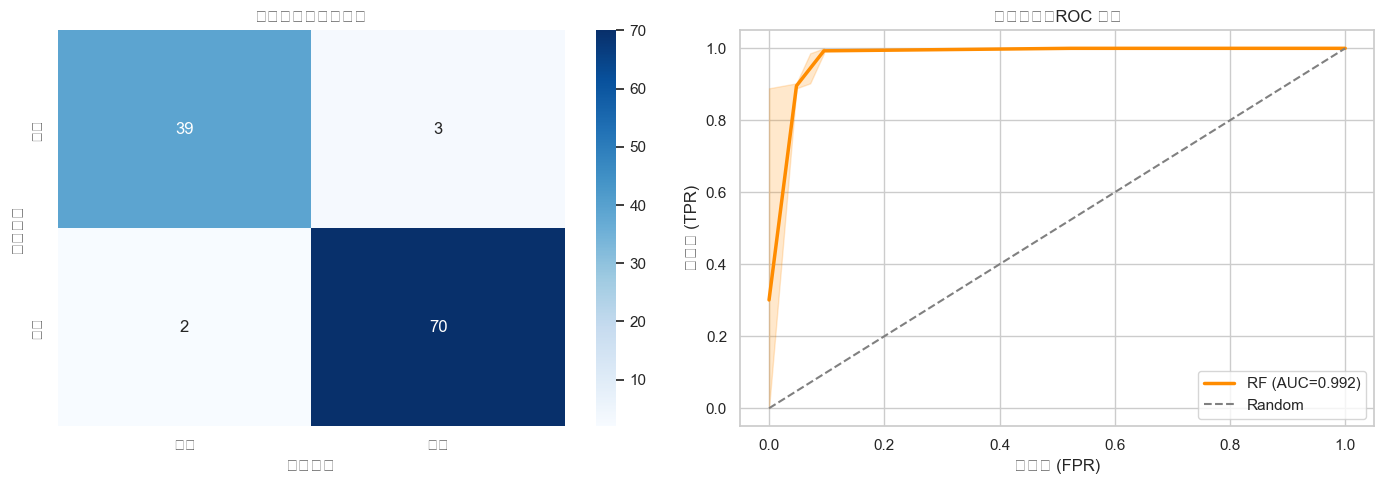

In [ ]:
# 4.RF 可视化：混淆矩阵 + ROC 曲线
sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'font.family': ['Microsoft YaHei', 'SimHei', 'Noto Sans SC', 'sans-serif'],
    'font.sans-serif': ['Microsoft YaHei', 'SimHei', 'Noto Sans SC', 'Microsoft JhengHei', 'sans-serif'],
    'axes.unicode_minus': False,
})

# 先打印核心评估指标
print(f'RF准确率:{accuracy_score(y_pred_rf, y_clf_test):.4f}')
print(f'RF精确率:{precision_score(y_pred_rf, y_clf_test):.4f}')
print(f'RF召回率:{recall_score(y_pred_rf, y_clf_test):.4f}')
print(f'RF F1-score:{f1_score(y_pred_rf, y_clf_test):.4f}')
print(f'RF ROC AUC:{roc_auc_score(y_clf_test, y_prob_rf):.4f}')
print(classification_report(y_pred_rf, y_clf_test, target_names=['恶性', '良性']))

# 可视化：两幅图并排
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) 混淆矩阵
cm = confusion_matrix(y_clf_test, y_pred_rf)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['恶性', '良性'],
    yticklabels=['恶性', '良性'],
    cbar=True,
    ax=axes[0]
)
axes[0].set_xlabel('预测标签')
axes[0].set_ylabel('真实标签')
axes[0].set_title('随机森林：混淆矩阵')

# 2) ROC 曲线
fpr, tpr, _ = roc_curve(y_clf_test, y_prob_rf)
roc_auc = roc_auc_score(y_clf_test, y_prob_rf)

sns.lineplot(x=fpr, y=tpr, ax=axes[1], label=f'RF (AUC={roc_auc:.3f})', color='darkorange', linewidth=2.5)
# 参考线：随机猜测
x_ref = np.linspace(0, 1, 100)
sns.lineplot(x=x_ref, y=x_ref, ax=axes[1], linestyle='--', color='gray', linewidth=1.5, label='Random')

axes[1].set_xlabel('假正率 (FPR)')
axes[1].set_ylabel('真正率 (TPR)')

axes[1].set_title('随机森林：ROC 曲线')plt.show()

axes[1].legend()plt.tight_layout()
